## UWAGA tu już używamy nowej wyczyszczonej ramki bez braków, z filmami roku 1980 itp

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv('../data/merged/NEW_clean_data.csv') # z notatnika NEW_cleaning

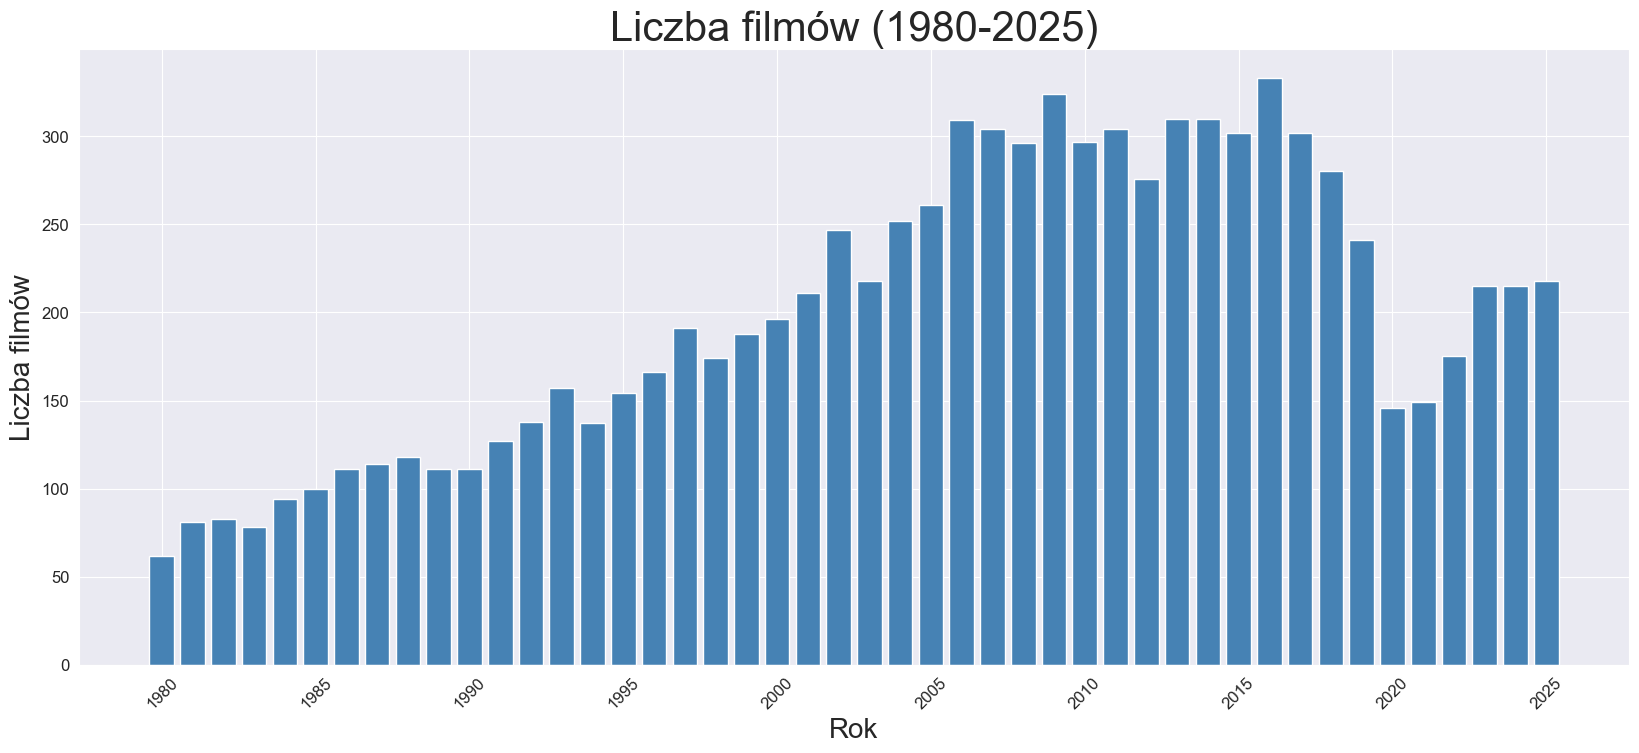

In [4]:
movies_per_year = data['year'].value_counts().sort_index()

plt.figure(figsize=(20, 8))
plt.bar(x = movies_per_year.index,
        height = movies_per_year.values,
        color='steelblue')

plt.title('Liczba filmów (1980-2025)', fontsize=30)
plt.xlabel('Rok', fontsize = 20)
plt.ylabel('Liczba filmów', fontsize = 20)

plt.xticks(movies_per_year.index[::5], rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.show()

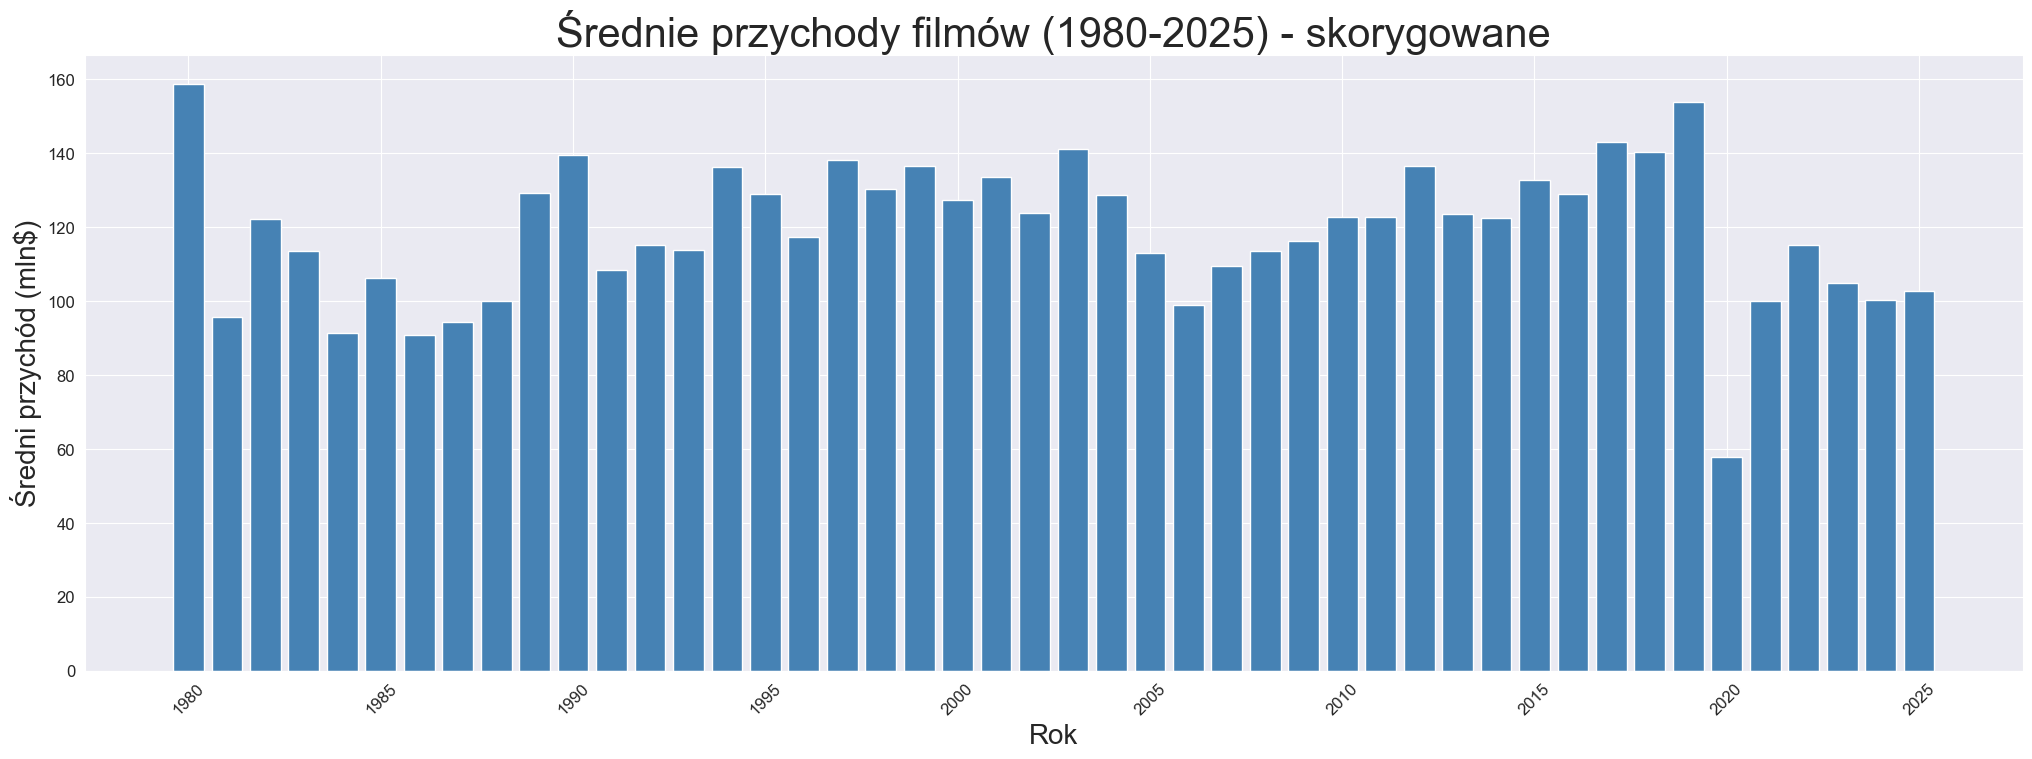

In [5]:
mean_revenue_year = data.groupby('year')['revenue_adjusted'].mean() / 1e6

plt.figure(figsize=(25, 8))
plt.bar(x = mean_revenue_year.index,
        height = mean_revenue_year.values,
        color='steelblue')

plt.title('Średnie przychody filmów (1980-2025) - skorygowane', fontsize=30)
plt.xlabel('Rok', fontsize = 20)
plt.ylabel('Średni przychód (mln$)', fontsize = 20)

plt.xticks(movies_per_year.index[::5], rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.show()

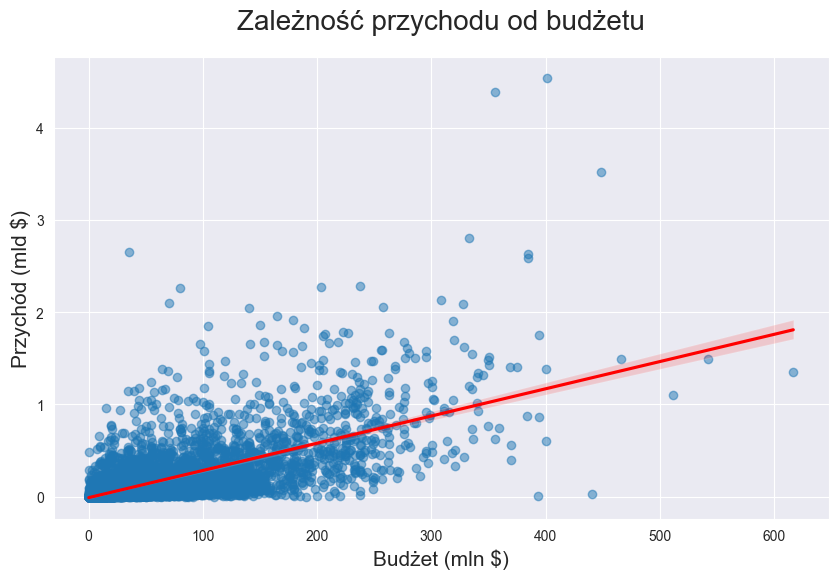

In [6]:
plt.figure(figsize = (10,6))
sns.regplot(x = data['budget_adjusted'] / 1e6, 
            y = data['revenue_adjusted'] / 1e9, 
            scatter_kws={'alpha': 0.5}, 
            line_kws={'color': 'red'})

plt.title('Zależność przychodu od budżetu', fontsize=20, pad=20)
plt.xlabel('Budżet (mln $)', fontsize=15)
plt.ylabel('Przychód (mld $)', fontsize=15)


plt.show()

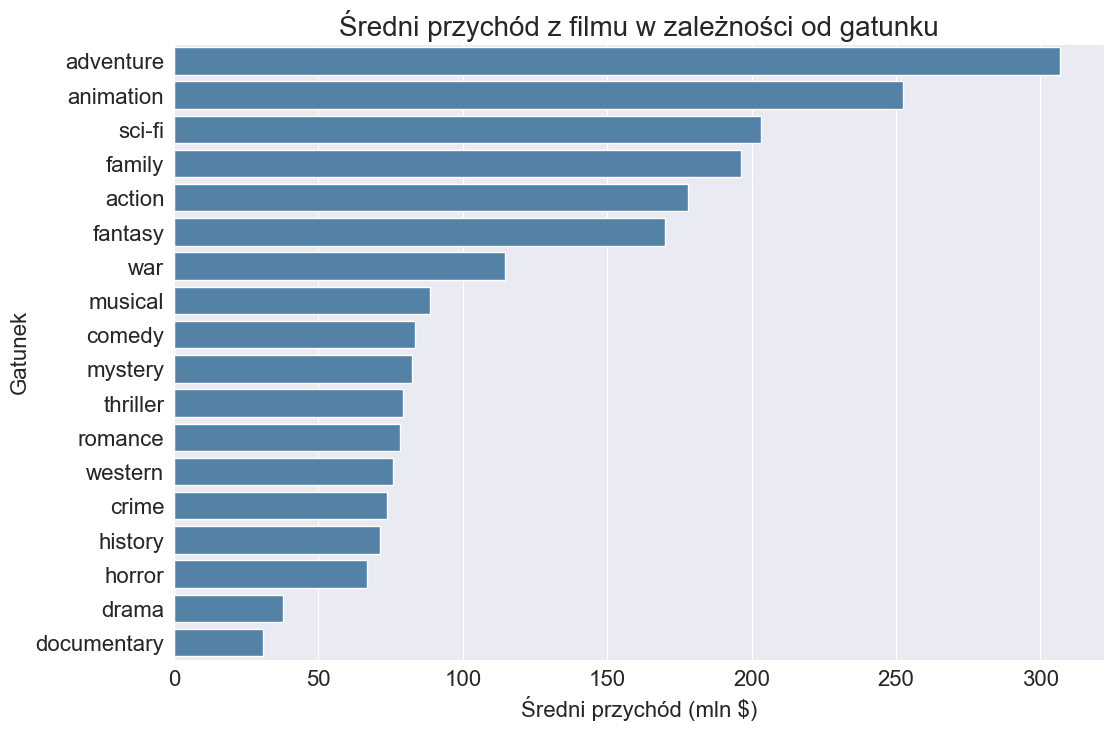

In [7]:
pl_data_rev = data[['revenue_adjusted', 'main_genre']].dropna().copy()
pl_data_rev['revenue_mln'] = pl_data_rev['revenue_adjusted'] / 1e6

plt.figure(figsize=(12, 8))

sns.barplot(
    data=pl_data_rev, 
    x='revenue_mln', 
    y='main_genre', 
    color='steelblue', 
    errorbar=None, 
    order=pl_data_rev.groupby('main_genre')['revenue_mln'].mean().sort_values(ascending=False).index 
)

plt.title('Średni przychód z filmu w zależności od gatunku', fontsize=20)
plt.xlabel('Średni przychód (mln $)', fontsize=16)
plt.ylabel('Gatunek', fontsize=16)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.show()

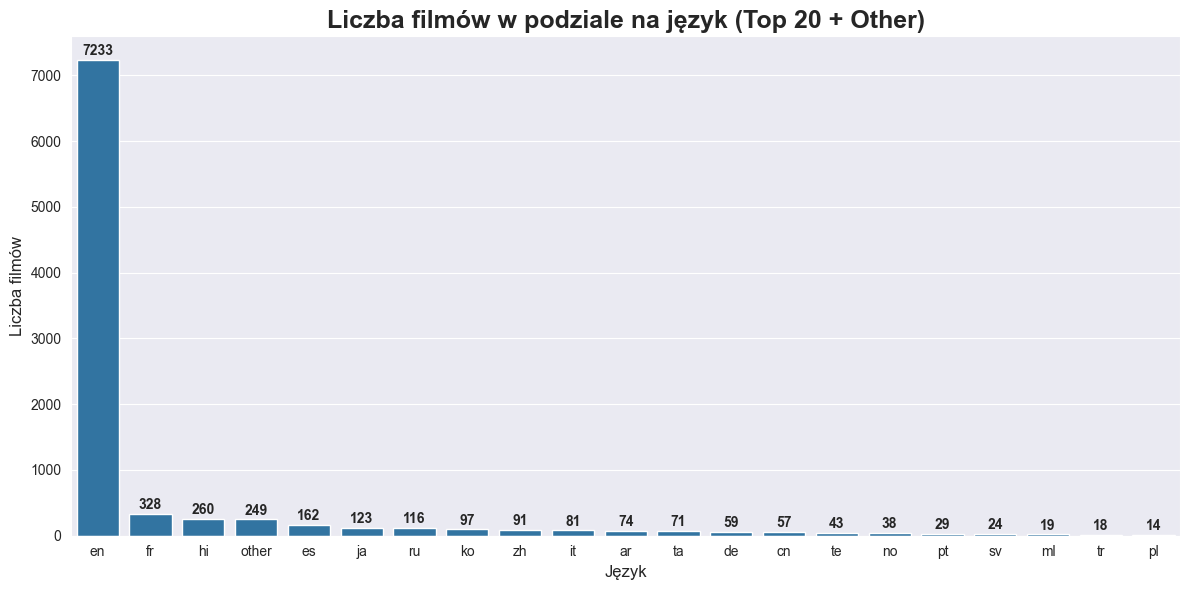

In [8]:
counts = data['original_language'].value_counts()


plt.figure(figsize=(12, 6))
sns.barplot(x=counts.index, y=counts.values)


plt.title('Liczba filmów w podziale na język (Top 20 + Other)', fontsize=18, fontweight='bold')
plt.xlabel('Język', fontsize=12)
plt.ylabel('Liczba filmów', fontsize=12)

for i, v in enumerate(counts.values):
    plt.text(i, v + (max(counts.values) * 0.01), str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\Gabi\AppData\Local\Temp\ipykernel_26748\3135524426.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(i, grupy[i], f"{p:.1f}%", ha='center', va='bottom')


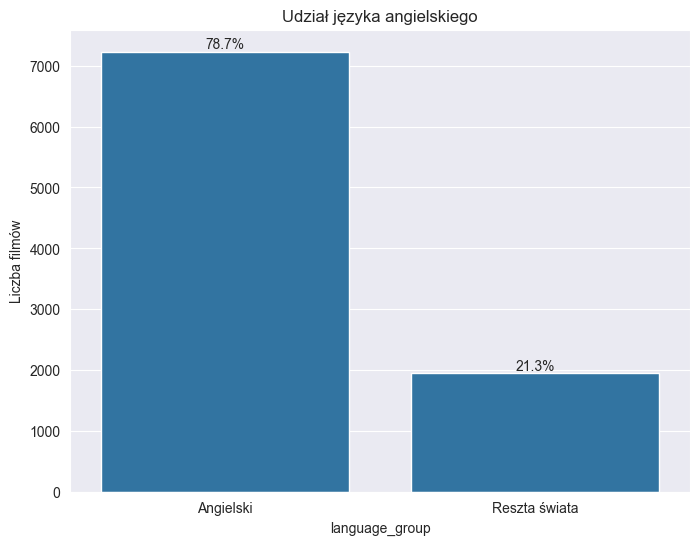

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Przygotowanie danych (grupy)
temp_data = data.copy()
temp_data['language_group'] = temp_data['original_language'].apply(
    lambda x: 'Angielski' if x == 'en' else 'Reszta świata'
)

grupy = temp_data['language_group'].value_counts()
procenty = (grupy / grupy.sum()) * 100

# 2. Wykres
plt.figure(figsize=(8, 6))
sns.barplot(x=grupy.index, y=grupy.values)

# 3. Dodanie samych procentów nad słupkami
for i, p in enumerate(procenty):
    plt.text(i, grupy[i], f"{p:.1f}%", ha='center', va='bottom')

plt.title('Udział języka angielskiego')
plt.ylabel('Liczba filmów')
plt.show()

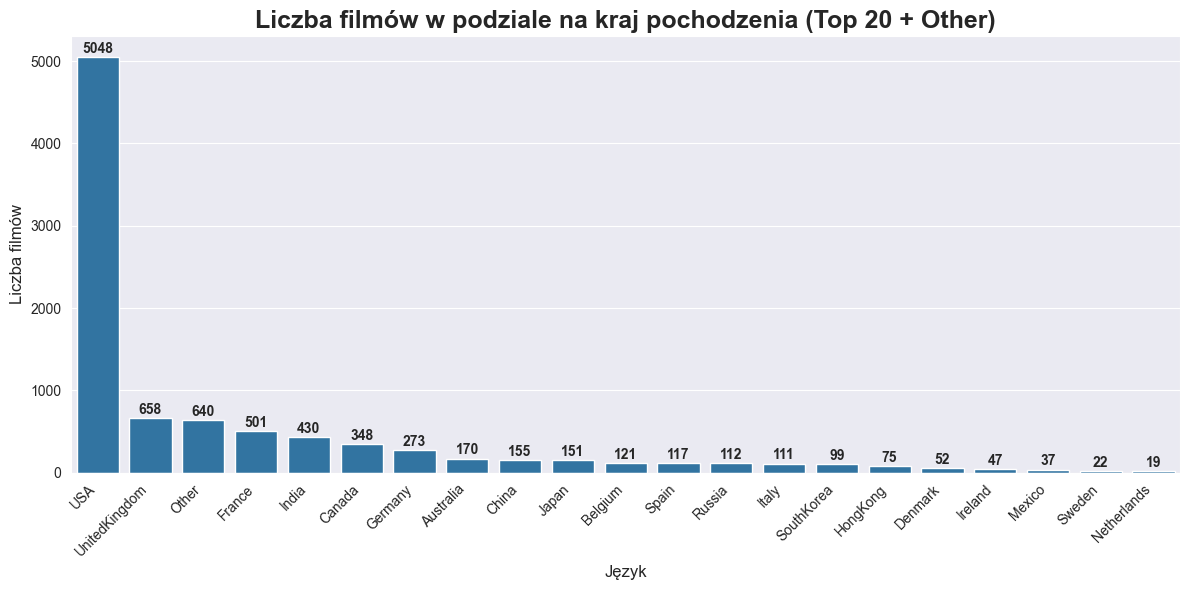

In [10]:
counts = data['main_country'].value_counts()


plt.figure(figsize=(12, 6))
sns.barplot(x=counts.index, y=counts.values)


plt.title('Liczba filmów w podziale na kraj pochodzenia (Top 20 + Other)', fontsize=18, fontweight='bold')
plt.xlabel('Język', fontsize=12)
plt.ylabel('Liczba filmów', fontsize=12)

for i, v in enumerate(counts.values):
    plt.text(i, v + (max(counts.values) * 0.01), str(v), ha='center', fontweight='bold')

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

C:\Users\Gabi\AppData\Local\Temp\ipykernel_26748\1131662435.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(i, grupy[i], f"{p:.1f}%", ha='center', va='bottom')


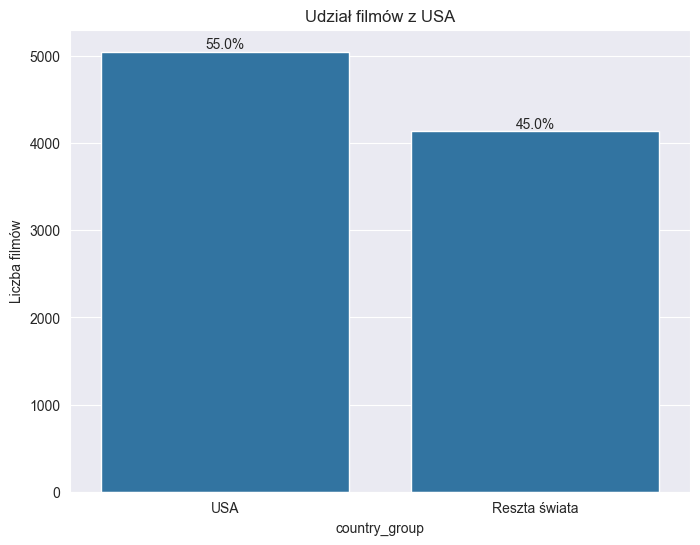

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Przygotowanie danych (grupy)
temp_data = data.copy()
temp_data['country_group'] = temp_data['main_country'].apply(
    lambda x: 'USA' if x == 'USA' else 'Reszta świata'
)

grupy = temp_data['country_group'].value_counts()
procenty = (grupy / grupy.sum()) * 100

# 2. Wykres
plt.figure(figsize=(8, 6))
sns.barplot(x=grupy.index, y=grupy.values)

# 3. Dodanie samych procentów nad słupkami
for i, p in enumerate(procenty):
    plt.text(i, grupy[i], f"{p:.1f}%", ha='center', va='bottom')

plt.title('Udział filmów z USA')
plt.ylabel('Liczba filmów')
plt.show()

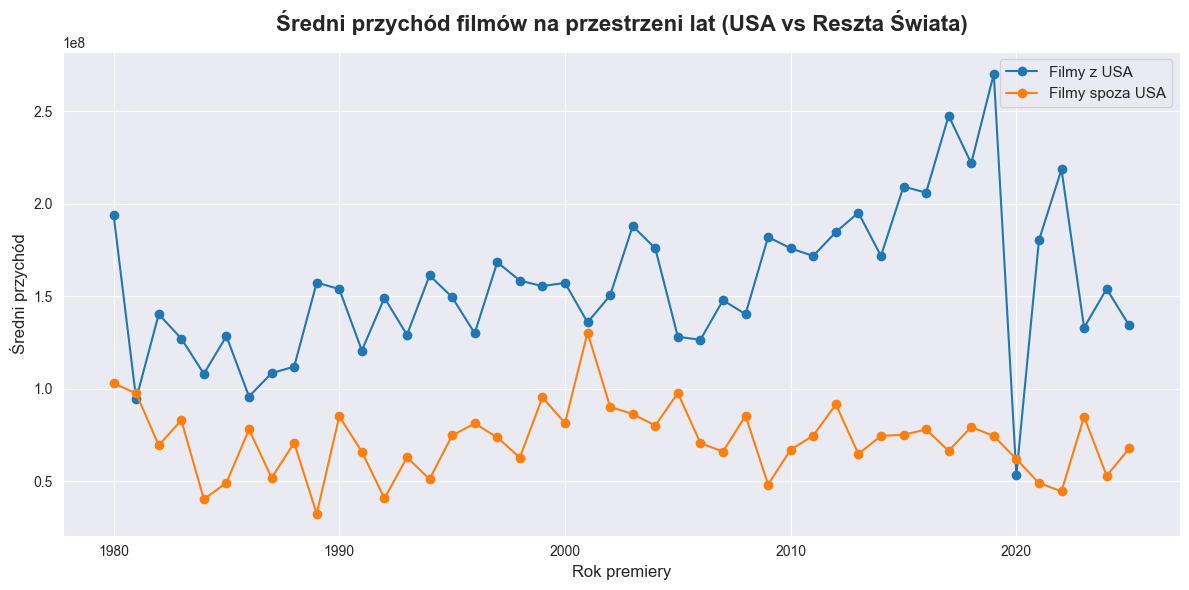

In [12]:

avg_revenue_us = data[data['main_country'] == 'USA'].groupby('year')['revenue_adjusted'].mean().reset_index()

avg_revenue_non_us = data[data['main_country'] != 'USA'].groupby('year')['revenue_adjusted'].mean().reset_index()

plt.figure(figsize=(12, 6))


plt.plot(avg_revenue_us['year'], avg_revenue_us['revenue_adjusted'], marker='o', label='Filmy z USA', color='#1f77b4')
plt.plot(avg_revenue_non_us['year'], avg_revenue_non_us['revenue_adjusted'], marker='o', label='Filmy spoza USA', color='#ff7f0e')


start_year = int(data['year'].min())
end_year = int(data['year'].max())
plt.xticks(range(start_year, end_year + 1, 10))


plt.title('Średni przychód filmów na przestrzeni lat (USA vs Reszta Świata)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Rok premiery', fontsize=12)
plt.ylabel('Średni przychód', fontsize=12)

plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

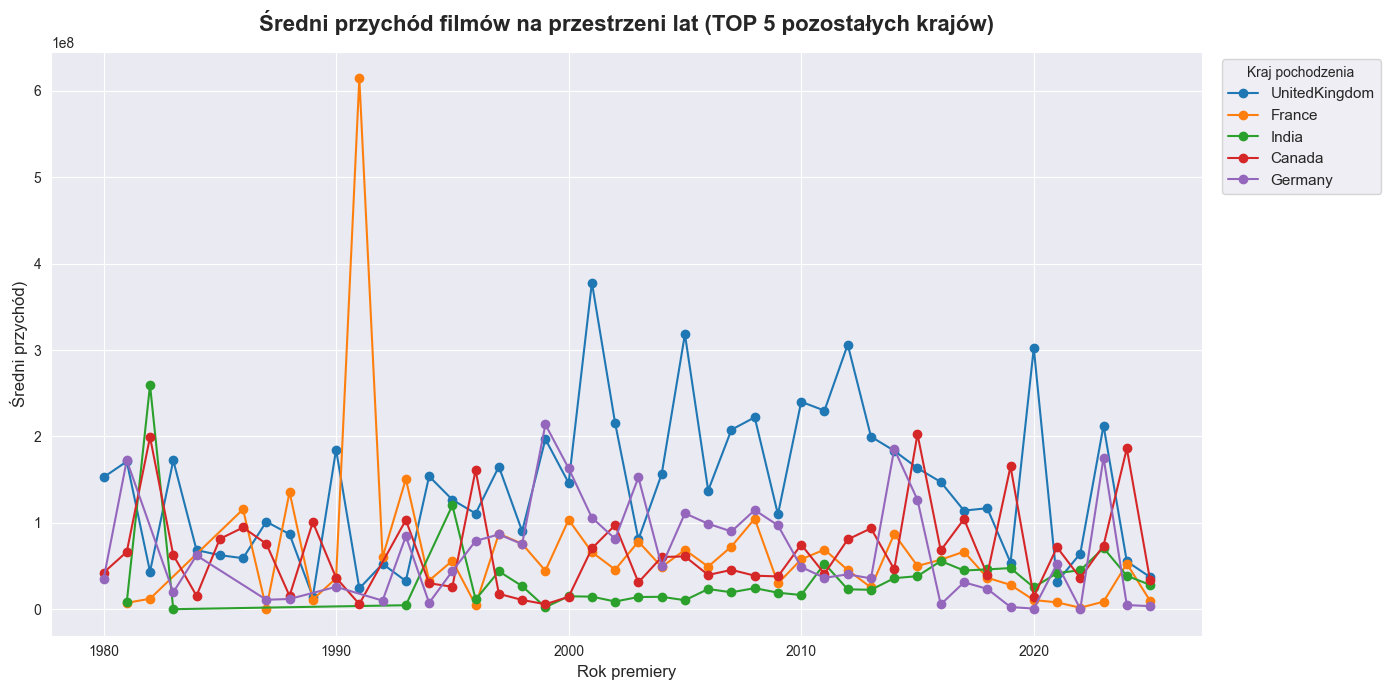

In [13]:

kraje_do_wykresu = ['UnitedKingdom',  'France', 'India', 'Canada', 'Germany']

plt.figure(figsize=(14, 7))


for kraj in kraje_do_wykresu:

    dane_kraju = data[data['main_country'] == kraj].groupby('year')['revenue_adjusted'].mean().reset_index()
    

    if not dane_kraju.empty:
        plt.plot(dane_kraju['year'], dane_kraju['revenue_adjusted'], marker='o', label=kraj)


start_year = int(data['year'].min())
end_year = int(data['year'].max())
plt.xticks(range(start_year, end_year + 1, 10))


plt.title('Średni przychód filmów na przestrzeni lat (TOP 5 pozostałych krajów)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Rok premiery', fontsize=12)
plt.ylabel('Średni przychód)', fontsize=12)

plt.legend(title='Kraj pochodzenia', fontsize=11, bbox_to_anchor=(1.01, 1), loc='upper left')


plt.tight_layout()
plt.show()

C:\Users\Gabi\AppData\Local\Temp\ipykernel_26748\1306301964.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_revenue_country.index, y=avg_revenue_country.values, palette='viridis')


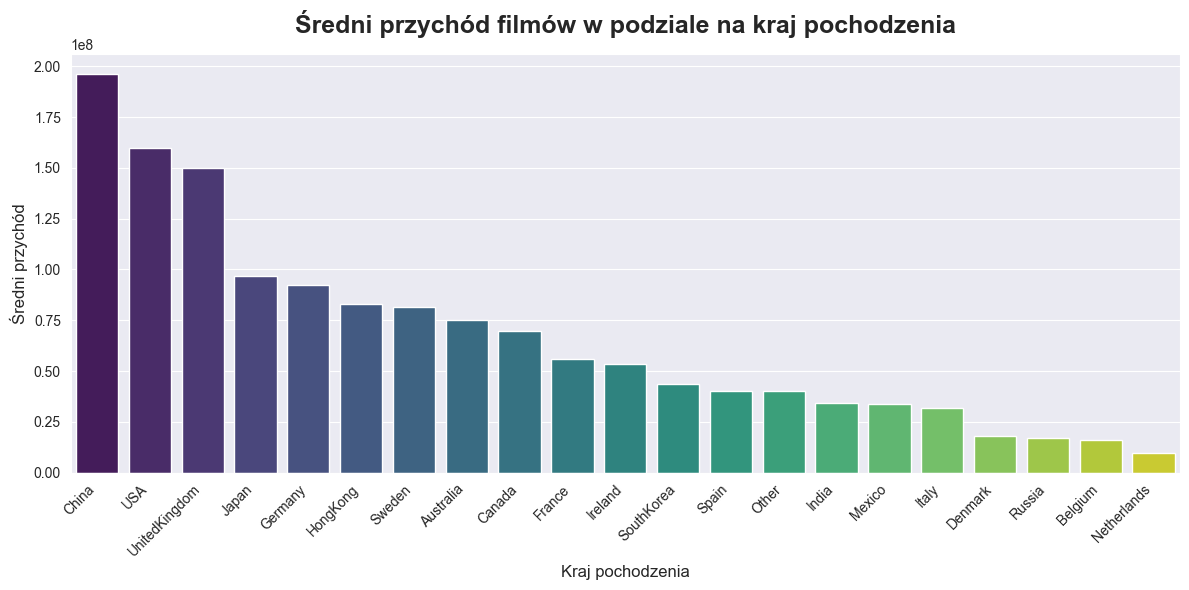

In [14]:
# 1. Grupujemy po kraju, liczymy średnią z przychodu i sortujemy od największego
avg_revenue_country = data.groupby('main_country')['revenue_adjusted'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))

# 2. Rysujemy wykres na podstawie nowych danych
sns.barplot(x=avg_revenue_country.index, y=avg_revenue_country.values, palette='viridis')

# 3. Zmienione tytuły i osie
plt.title('Średni przychód filmów w podziale na kraj pochodzenia', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Kraj pochodzenia', fontsize=12)
plt.ylabel('Średni przychód', fontsize=12)


plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

C:\Users\Gabi\AppData\Local\Temp\ipykernel_26748\1362062482.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='revenue_adjusted', y='title', data=cameron_data, palette='Blues_r')


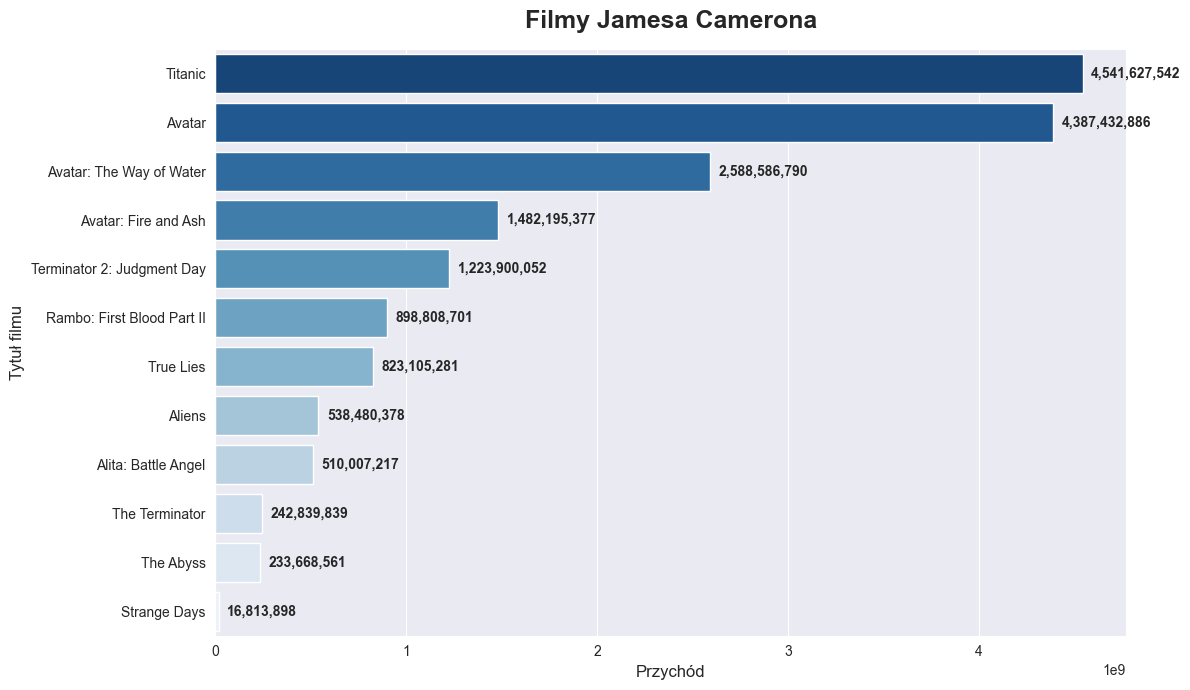

In [15]:
cameron_data = data[data['director_name'].str.contains('James Cameron', case=False, na=False)].copy()

cameron_data = cameron_data.sort_values('revenue_adjusted', ascending=False)


plt.figure(figsize=(12, 7))
sns.barplot(x='revenue_adjusted', y='title', data=cameron_data, palette='Blues_r')


plt.title('Filmy Jamesa Camerona', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Przychód', fontsize=12)
plt.ylabel('Tytuł filmu', fontsize=12)


for i, v in enumerate(cameron_data['revenue_adjusted']):
    plt.text(v + (max(cameron_data['revenue_adjusted']) * 0.01), i, f"{v:,.0f}", va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

In [16]:
data[data["revenue_adjusted"] > 1e9]

,tmdbId,title,release_date,runtime,original_language,vote_average,vote_count,origin_countries,spoken_languages,year,...,actor3_max_revenue,actor4_avg_revenue,actor4_max_revenue,actor5_avg_revenue,actor5_max_revenue,actors_avg_revenue,actors_max_revenue,female_actors,top_people_number,top_people
2,12.0,Finding Nemo,2003-05-30,100,en,7.817,20364,UnitedStatesofAmerica,English,2003,...,1.645296e+09,1.645296e+09,1.645296e+09,1.645296e+09,1.645296e+09,8.257942e+08,1.645296e+09,0,4,True
3,13.0,Forrest Gump,1994-06-23,142,en,8.500,29387,UnitedStatesofAmerica,English,1994,...,1.471527e+09,4.124310e+08,1.471527e+09,2.926597e+08,1.471527e+09,3.865216e+08,1.513240e+09,3,4,True
8,22.0,Pirates of the Caribbean: The Curse of the Bla...,2003-07-09,143,en,7.820,21982,UnitedStatesofAmerica,English,2003,...,1.702625e+09,6.374607e+08,1.702625e+09,1.032939e+09,1.493232e+09,5.859419e+08,1.660746e+09,2,2,True
16,58.0,Pirates of the Caribbean: Dead Man's Chest,2006-07-06,151,en,7.374,16968,UnitedStatesofAmerica,"English, Türkçe, ελληνικά, 普通话",2006,...,1.702625e+09,6.374607e+08,1.702625e+09,4.802903e+08,1.702625e+09,4.754121e+08,1.702625e+09,2,2,True
38,85.0,Raiders of the Lost Ark,1981-06-12,115,en,7.923,13462,UnitedStatesofAmerica,"English, Español, Deutsch, עִבְרִית, العربية,",1981,...,1.381011e+09,1.381011e+09,1.381011e+09,1.381011e+09,1.381011e+09,8.947321e+08,1.525523e+09,1,3,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8674,872585.0,Oppenheimer,2023-07-19,181,en,8.034,11493,"UnitedKingdom, UnitedStatesofAmerica","Nederlands, English",2023,...,1.005867e+09,7.843370e+08,2.631391e+09,1.005867e+09,1.005867e+09,5.068995e+08,1.330972e+09,1,4,True
8802,980477.0,Ne Zha 2,2025-01-29,144,zh,8.122,625,China,普通话,2025,...,2.259822e+09,2.259822e+09,2.259822e+09,2.259822e+09,2.259822e+09,2.127369e+09,2.259822e+09,2,0,False
8882,1022789.0,Inside Out 2,2024-06-11,97,en,7.547,6530,UnitedStatesofAmerica,English,2024,...,1.743565e+09,9.912636e+08,1.743565e+09,1.743565e+09,1.743565e+09,1.432600e+09,1.743565e+09,4,0,False
8950,1084242.0,Zootopia 2,2025-11-26,108,en,7.608,2290,"UnitedStatesofAmerica, Canada",English,2025,...,1.861045e+09,9.506709e+08,1.861045e+09,1.861045e+09,1.861045e+09,9.794299e+08,1.861045e+09,2,0,False


C:\Users\Gabi\AppData\Local\Temp\ipykernel_26748\3157346243.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='revenue_adjusted', y='title', data=cameron_data, palette='Blues_r')


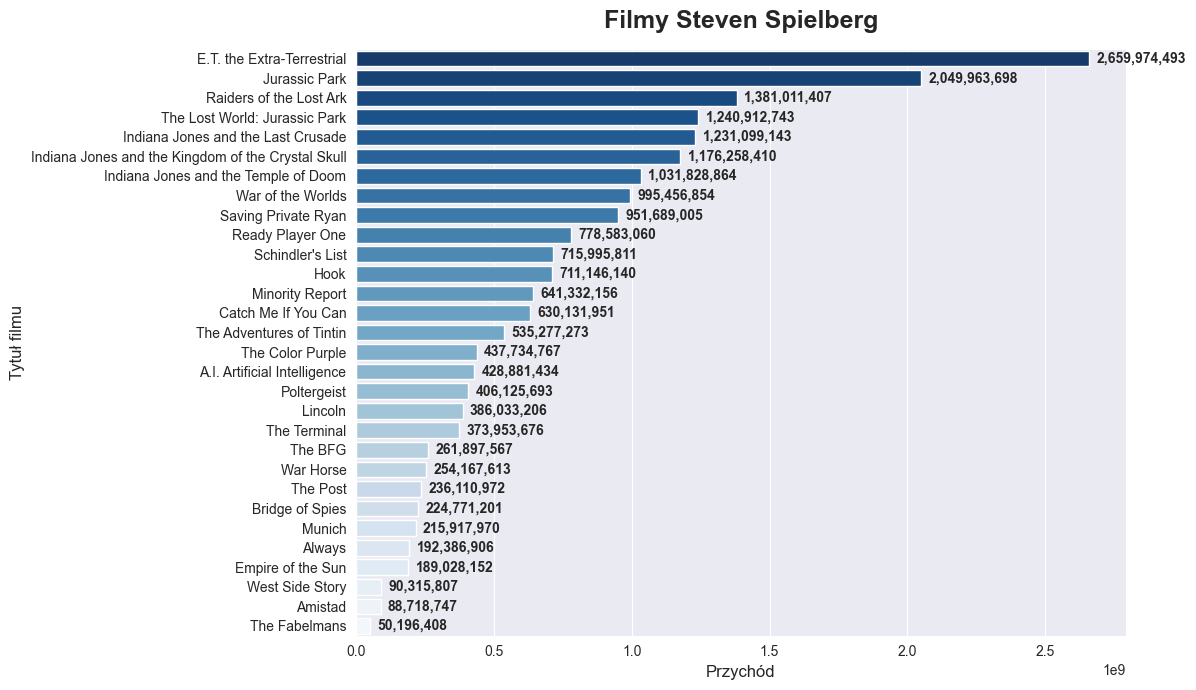

In [17]:
cameron_data = data[data['director_name'].str.contains('Steven Spielberg', case=False, na=False)].copy()

cameron_data = cameron_data.sort_values('revenue_adjusted', ascending=False)


plt.figure(figsize=(12, 7))
sns.barplot(x='revenue_adjusted', y='title', data=cameron_data, palette='Blues_r')


plt.title('Filmy Steven Spielberg', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Przychód', fontsize=12)
plt.ylabel('Tytuł filmu', fontsize=12)


for i, v in enumerate(cameron_data['revenue_adjusted']):
    plt.text(v + (max(cameron_data['revenue_adjusted']) * 0.01), i, f"{v:,.0f}", va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

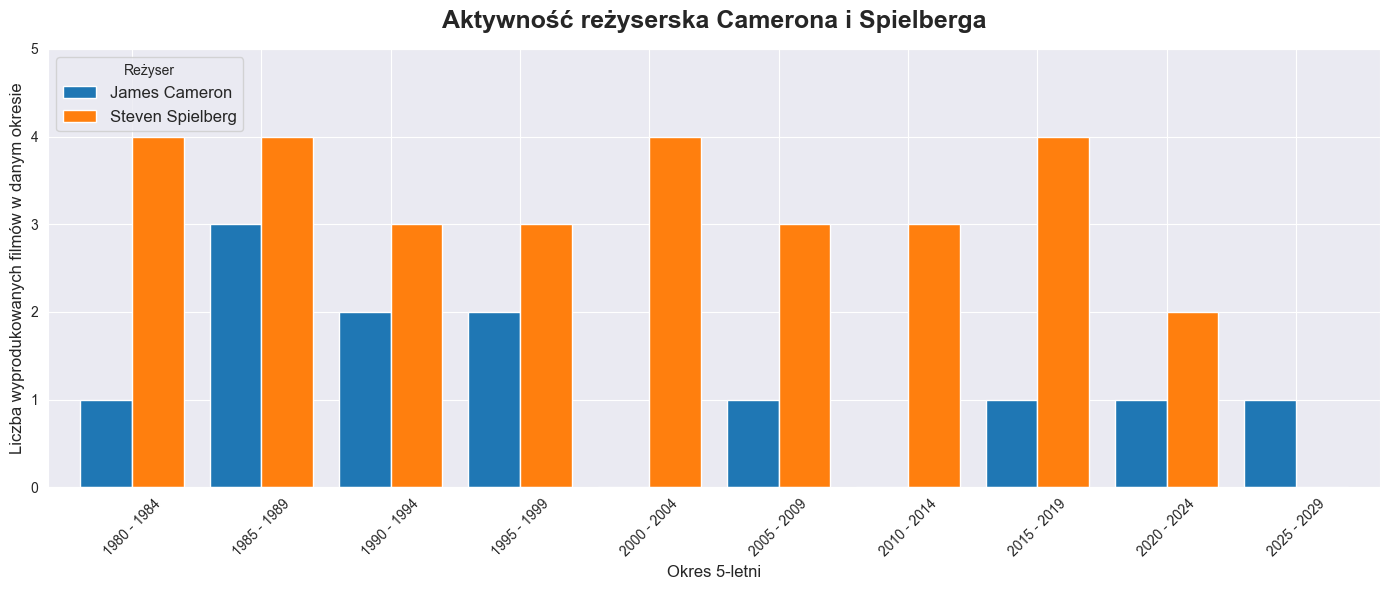

In [18]:
import matplotlib.pyplot as plt

cameron_spielberg = data[data['director_name'].str.contains('James Cameron|Steven Spielberg', case=False, na=False)].copy()

def get_director_name(name):
    if 'James Cameron' in str(name): return 'James Cameron'
    elif 'Steven Spielberg' in str(name): return 'Steven Spielberg'
    return 'Other'

cameron_spielberg['Director_Name'] = cameron_spielberg['director_name'].apply(get_director_name)

cameron_spielberg['5_year_period'] = (cameron_spielberg['year'] // 5) * 5


period_counts = cameron_spielberg.groupby(['5_year_period', 'Director_Name']).size().unstack(fill_value=0)
min_period = int(cameron_spielberg['5_year_period'].min())
max_period = int(cameron_spielberg['5_year_period'].max())

period_counts = period_counts.reindex(range(min_period, max_period + 1, 5), fill_value=0)

ax = period_counts.plot(kind='bar', figsize=(14, 6), width=0.8, color=['#1f77b4', '#ff7f0e'])

plt.title('Aktywność reżyserska Camerona i Spielberga', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Okres 5-letni', fontsize=12)
plt.ylabel('Liczba wyprodukowanych filmów w danym okresie', fontsize=12)


ax.set_xticklabels([f"{int(x)} - {int(x)+4}" for x in period_counts.index], rotation=45)


max_films = int(period_counts.max().max())
plt.yticks(range(0, max_films + 2))

plt.legend(title='Reżyser', fontsize=12, loc='upper left')
plt.tight_layout()
plt.show()

Wpływ cech związanych z popularnością ludzi

In [22]:
data

,tmdbId,title,release_date,runtime,original_language,vote_average,vote_count,origin_countries,spoken_languages,year,...,actor3_max_revenue,actor4_avg_revenue,actor4_max_revenue,actor5_avg_revenue,actor5_max_revenue,actors_avg_revenue,actors_max_revenue,female_actors,top_people_number,top_people
0,5.0,Four Rooms,1995-12-09,98,en,5.892,2810,UnitedStatesofAmerica,English,1995,...,2.889085e+07,1.979667e+07,2.889085e+07,1.078966e+08,3.039070e+08,3.948193e+07,1.086683e+08,3,2,True
1,6.0,Judgment Night,1993-10-15,109,en,6.469,368,UnitedStatesofAmerica,English,1993,...,6.691507e+07,8.920569e+07,1.554244e+08,1.758768e+08,6.302019e+08,7.128450e+07,1.813246e+08,0,0,False
2,12.0,Finding Nemo,2003-05-30,100,en,7.817,20364,UnitedStatesofAmerica,English,2003,...,1.645296e+09,1.645296e+09,1.645296e+09,1.645296e+09,1.645296e+09,8.257942e+08,1.645296e+09,0,4,True
3,13.0,Forrest Gump,1994-06-23,142,en,8.500,29387,UnitedStatesofAmerica,English,1994,...,1.471527e+09,4.124310e+08,1.471527e+09,2.926597e+08,1.471527e+09,3.865216e+08,1.513240e+09,3,4,True
4,14.0,American Beauty,1999-09-15,122,en,8.000,12880,UnitedStatesofAmerica,English,1999,...,6.885186e+08,1.374697e+08,6.885186e+08,3.446150e+08,6.885186e+08,1.829980e+08,7.001017e+08,3,6,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9181,1500536.0,Dead to Rights,2025-07-19,137,zh,8.000,73,China,"普通话, 日本語",2025,...,4.227859e+08,4.227859e+08,4.227859e+08,4.227859e+08,4.227859e+08,4.227859e+08,4.227859e+08,1,0,False
9182,1511417.0,Bāhubali: The Epic,2025-10-29,224,te,5.985,34,India,"?????, हिन्दी, , தமிழ், తెలుగు",2025,...,3.500000e+06,3.500000e+06,3.500000e+06,1.860871e+08,3.686741e+08,6.572882e+07,1.530714e+08,2,0,False
9183,1518784.0,Witnessed,2023-05-06,88,en,10.000,2,NaN,English,2023,...,5.599891e+04,5.599891e+04,5.599891e+04,5.599891e+04,5.599891e+04,5.599891e+04,5.599891e+04,1,0,False
9184,1537715.0,Banduan,2025-11-06,127,other,6.500,2,Malaysia,Bahasa melayu,2025,...,1.472934e+06,1.472934e+06,1.472934e+06,1.472934e+06,1.472934e+06,1.369927e+06,1.472934e+06,0,0,False


In [44]:
corr = data[['runtime', 'vote_average', 'vote_count', 'quarter', 'director_movie_count', 'writer_movie_count', 'actors_avg_movie_count', 'writer_avg_revenue', 'writer_max_revenue', 'director_avg_revenue', 'director_max_revenue', 'actors_avg_revenue', 'actors_max_revenue', 'female_actors', 'top_people_number', 'top_people', 'budget_adjusted', 'revenue_adjusted']].corr()

fig, ax = plt.subplots(figsize=(15, 10))
sns.heatmap(corr, cmap='vlag', annot=True, ax=ax)
plt.show()

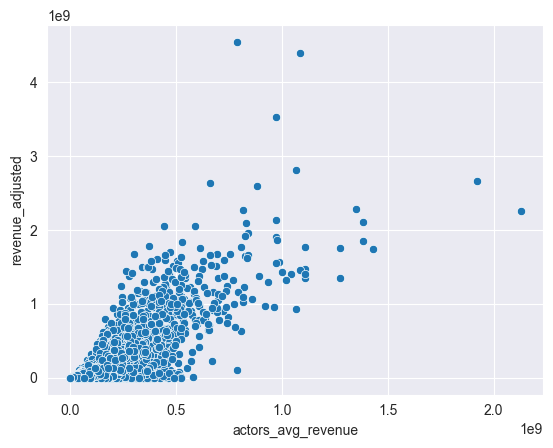

In [47]:
sns.scatterplot(x='actors_avg_revenue', y='revenue_adjusted', data=data)
plt.show()

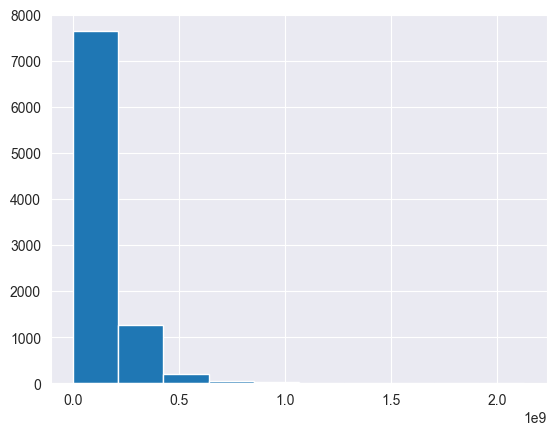

In [57]:
data['actors_avg_revenue'].hist()
plt.show()

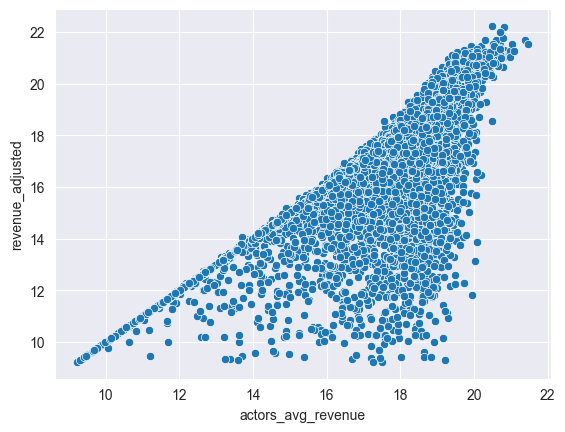

In [60]:
import numpy as np

sns.scatterplot(
    x=np.log1p(data['actors_avg_revenue']),
    y=np.log1p(data['revenue_adjusted'])
)
plt.show()